# Exercise "vec"

In this exercise a C++ class `vec` is implemented for ordinary Euclidean 3D vectors.

The class contains three `double` components `x`, `y`, and `z`, and implements constructors, destructor, copy/move semantics, operator overloading, vector addition/subtraction, scalar multiplication/division, dot product, cross product, norm, printing, and approximate comparison.

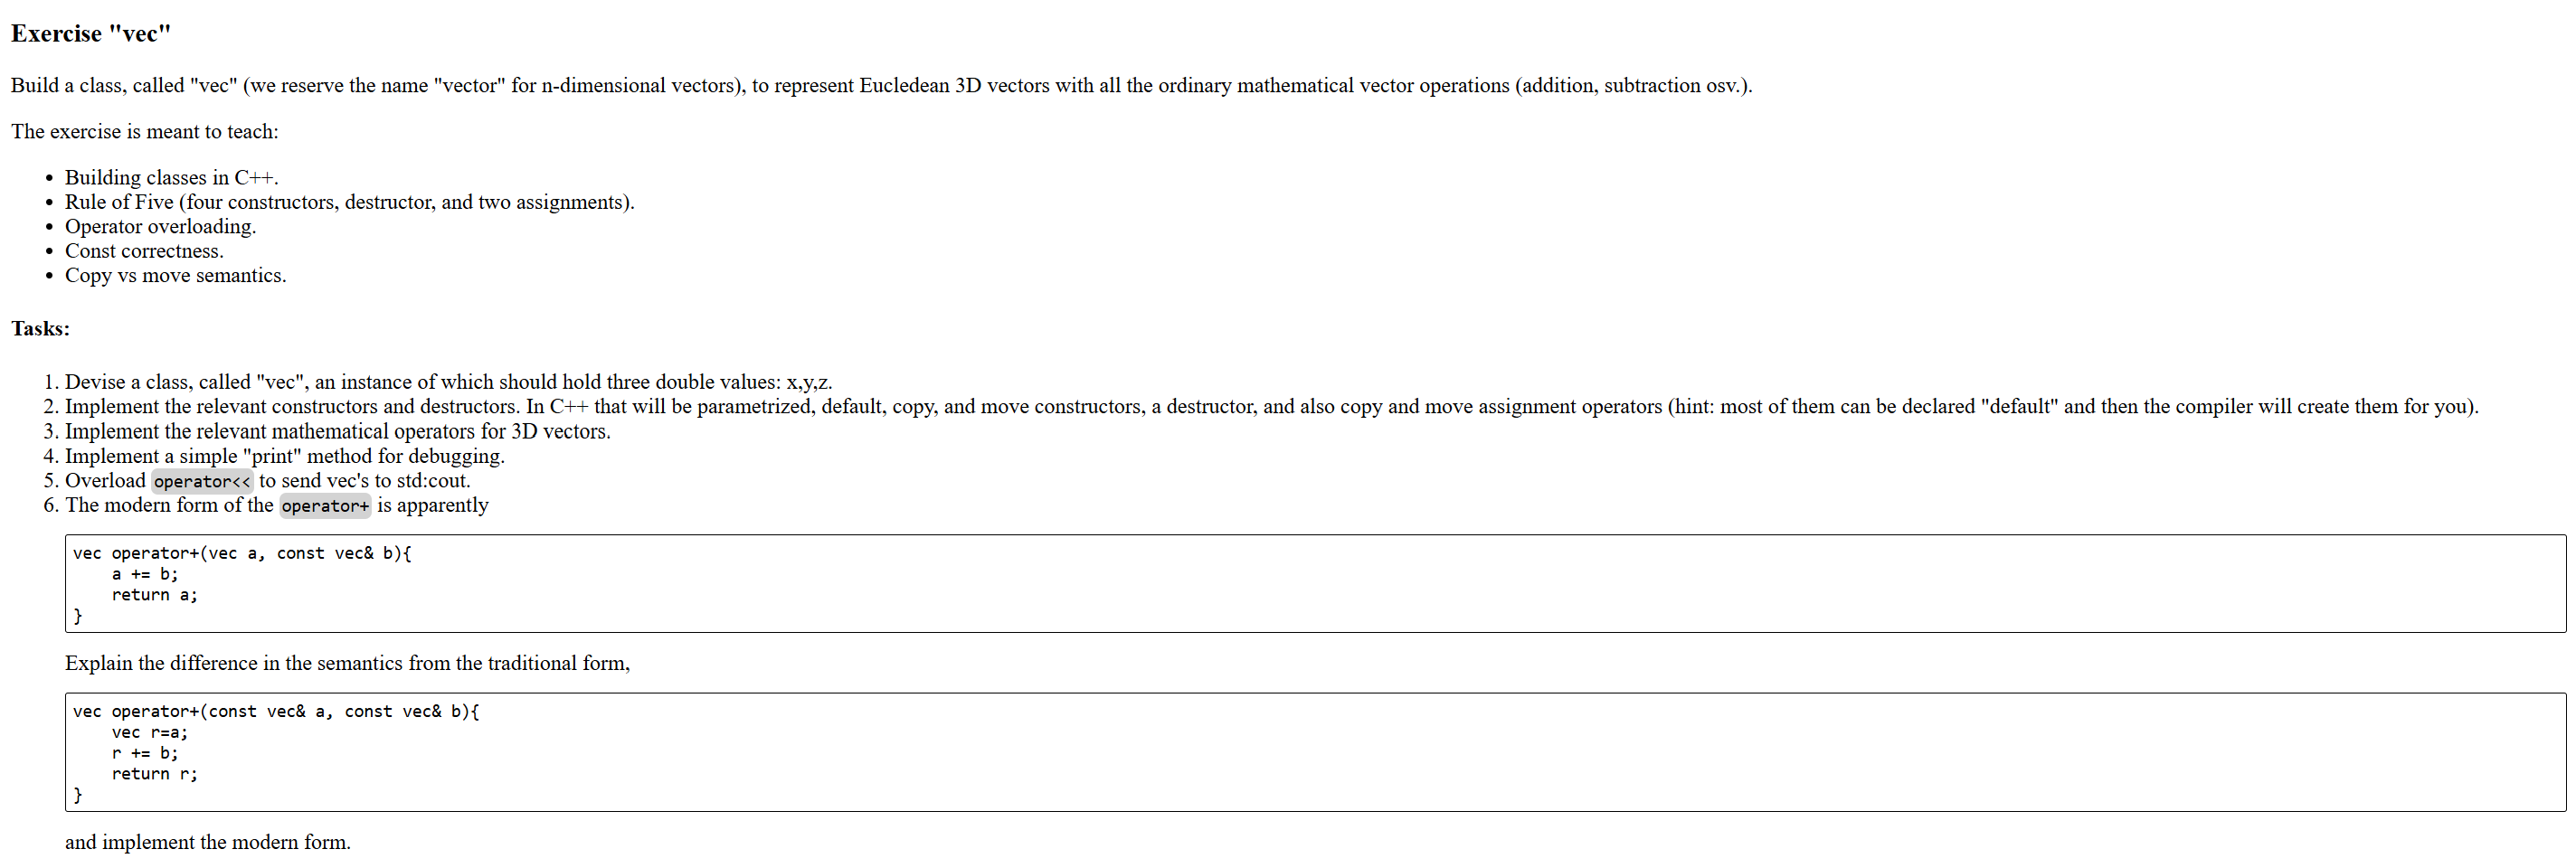

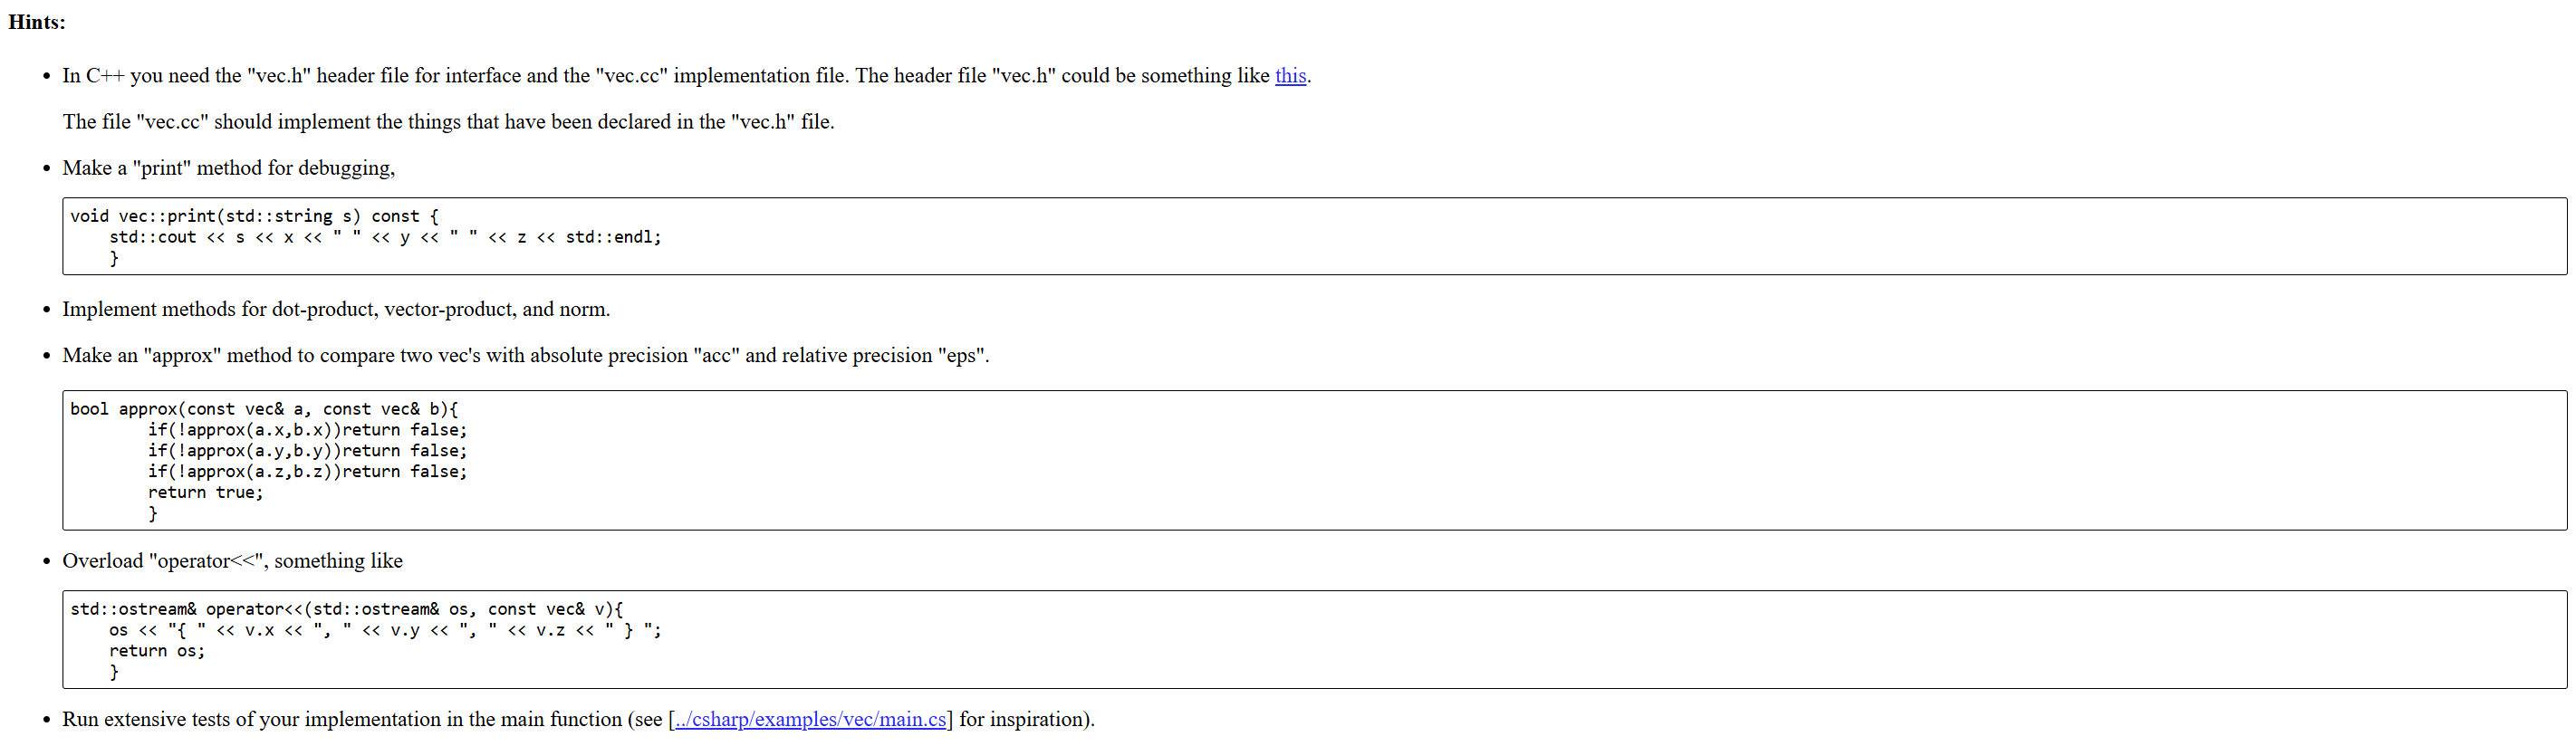

In [1]:
from pathlib import Path

Path("vec.h").write_text(r'''
#pragma once

#include <iostream>
#include <string>

class vec {
public:
    double x;
    double y;
    double z;

    // Constructors and rule of five
    vec();
    vec(double x, double y, double z);

    vec(const vec& other) = default;
    vec(vec&& other) noexcept = default;

    ~vec() = default;

    vec& operator=(const vec& other) = default;
    vec& operator=(vec&& other) noexcept = default;

    // Compound operators
    vec& operator+=(const vec& other);
    vec& operator-=(const vec& other);
    vec& operator*=(double c);
    vec& operator/=(double c);

    // Vector operations
    double dot(const vec& other) const;
    vec cross(const vec& other) const;
    double norm() const;

    // Debug print
    void print(const std::string& s = "") const;
};

// Modern non-member operators
vec operator+(vec a, const vec& b);
vec operator-(vec a, const vec& b);
vec operator-(vec a);

vec operator*(vec a, double c);
vec operator*(double c, vec a);
vec operator/(vec a, double c);

// Free vector functions
double dot(const vec& a, const vec& b);
vec cross(const vec& a, const vec& b);

// Approximate comparison
bool approx(double a, double b, double acc = 1e-9, double eps = 1e-9);
bool approx(const vec& a, const vec& b, double acc = 1e-9, double eps = 1e-9);

// Output operator
std::ostream& operator<<(std::ostream& os, const vec& v);
''')

print("Wrote vec.h")

Wrote vec.h


In [2]:
from pathlib import Path

Path("vec.cc").write_text(r'''
#include "vec.h"

#include <algorithm>
#include <cmath>
#include <stdexcept>

// Constructors
vec::vec() : x(0.0), y(0.0), z(0.0) {}

vec::vec(double x_, double y_, double z_) : x(x_), y(y_), z(z_) {}

// Compound operators
vec& vec::operator+=(const vec& other) {
    x += other.x;
    y += other.y;
    z += other.z;
    return *this;
}

vec& vec::operator-=(const vec& other) {
    x -= other.x;
    y -= other.y;
    z -= other.z;
    return *this;
}

vec& vec::operator*=(double c) {
    x *= c;
    y *= c;
    z *= c;
    return *this;
}

vec& vec::operator/=(double c) {
    if (c == 0.0) {
        throw std::runtime_error("division by zero in vec::operator/=");
    }

    x /= c;
    y /= c;
    z /= c;
    return *this;
}

// Vector operations
double vec::dot(const vec& other) const {
    return x*other.x + y*other.y + z*other.z;
}

vec vec::cross(const vec& other) const {
    return vec(
        y*other.z - z*other.y,
        z*other.x - x*other.z,
        x*other.y - y*other.x
    );
}

double vec::norm() const {
    return std::sqrt(this->dot(*this));
}

void vec::print(const std::string& s) const {
    std::cout << s << "(" << x << ", " << y << ", " << z << ")\n";
}

// Modern non-member operators
vec operator+(vec a, const vec& b) {
    a += b;
    return a;
}

vec operator-(vec a, const vec& b) {
    a -= b;
    return a;
}

vec operator-(vec a) {
    a *= -1.0;
    return a;
}

vec operator*(vec a, double c) {
    a *= c;
    return a;
}

vec operator*(double c, vec a) {
    a *= c;
    return a;
}

vec operator/(vec a, double c) {
    a /= c;
    return a;
}

// Free functions
double dot(const vec& a, const vec& b) {
    return a.dot(b);
}

vec cross(const vec& a, const vec& b) {
    return a.cross(b);
}

// Approximate comparison
bool approx(double a, double b, double acc, double eps) {
    double diff = std::abs(a - b);

    if (diff <= acc) {
        return true;
    }

    double max_ab = std::max(std::abs(a), std::abs(b));

    if (diff <= eps * max_ab) {
        return true;
    }

    return false;
}

bool approx(const vec& a, const vec& b, double acc, double eps) {
    return approx(a.x, b.x, acc, eps)
        && approx(a.y, b.y, acc, eps)
        && approx(a.z, b.z, acc, eps);
}

// Output operator
std::ostream& operator<<(std::ostream& os, const vec& v) {
    os << "{ " << v.x << ", " << v.y << ", " << v.z << " }";
    return os;
}
''')

print("Wrote vec.cc")

Wrote vec.cc


In [3]:
from pathlib import Path

Path("vec_main.cc").write_text(r'''
#include "vec.h"

#include <cmath>
#include <iomanip>
#include <iostream>
#include <string>
#include <utility>

void print_check(const std::string& name, bool ok) {
    std::cout << std::left << std::setw(32) << name
              << " : " << (ok ? "OK" : "FAILED") << "\n";
}

int main() {
    std::cout << std::setprecision(15);

    std::cout << "Exercise: vec\n";
    std::cout << "=============\n\n";

    vec a(1.0, 2.0, 3.0);
    vec b(4.0, 5.0, 6.0);

    std::cout << "Input vectors\n";
    std::cout << "-------------\n";
    std::cout << "a = " << a << "\n";
    std::cout << "b = " << b << "\n\n";

    std::cout << "Basic vector operations\n";
    std::cout << "-----------------------\n";

    vec sum = a + b;
    vec diff = a - b;
    vec minus_a = -a;
    vec scalar_left = 2.0 * a;
    vec scalar_right = a * 2.0;
    vec division = b / 2.0;

    std::cout << "a + b   = " << sum << "\n";
    std::cout << "a - b   = " << diff << "\n";
    std::cout << "-a      = " << minus_a << "\n";
    std::cout << "2*a     = " << scalar_left << "\n";
    std::cout << "a*2     = " << scalar_right << "\n";
    std::cout << "b/2     = " << division << "\n\n";

    std::cout << "Dot product, cross product, and norm\n";
    std::cout << "------------------------------------\n";

    double ab_dot = dot(a, b);
    vec ab_cross = cross(a, b);
    double a_norm = a.norm();

    std::cout << "dot(a,b)   = " << ab_dot << "\n";
    std::cout << "cross(a,b) = " << ab_cross << "\n";
    std::cout << "norm(a)    = " << a_norm << "\n\n";

    std::cout << "Tests\n";
    std::cout << "-----\n";

    print_check("a+b = {5,7,9}", approx(sum, vec(5.0, 7.0, 9.0)));
    print_check("a-b = {-3,-3,-3}", approx(diff, vec(-3.0, -3.0, -3.0)));
    print_check("-a = {-1,-2,-3}", approx(minus_a, vec(-1.0, -2.0, -3.0)));
    print_check("2*a = {2,4,6}", approx(scalar_left, vec(2.0, 4.0, 6.0)));
    print_check("a*2 = {2,4,6}", approx(scalar_right, vec(2.0, 4.0, 6.0)));
    print_check("b/2 = {2,2.5,3}", approx(division, vec(2.0, 2.5, 3.0)));
    print_check("dot(a,b) = 32", approx(ab_dot, 32.0));
    print_check("cross(a,b) = {-3,6,-3}", approx(ab_cross, vec(-3.0, 6.0, -3.0)));
    print_check("norm(a) = sqrt(14)", approx(a_norm, std::sqrt(14.0)));

    std::cout << "\nCopy and move tests\n";
    std::cout << "-------------------\n";

    vec copy_constructed(a);
    vec copy_assigned;
    copy_assigned = b;

    vec move_constructed(std::move(copy_constructed));
    vec move_assigned;
    move_assigned = std::move(copy_assigned);

    print_check("copy constructor", approx(move_constructed, a));
    print_check("copy/move assignment", approx(move_assigned, b));

    std::cout << "\nOperator+ semantics\n";
    std::cout << "------------------\n";
    std::cout << "The modern operator+ has the form\n\n";
    std::cout << "    vec operator+(vec a, const vec& b) { a += b; return a; }\n\n";
    std::cout << "Here the left argument is passed by value. This creates the result object directly\n";
    std::cout << "from the left operand. Then b is added to it using operator+=. If the left operand\n";
    std::cout << "is a temporary object, it can be moved instead of copied. This is shorter and often\n";
    std::cout << "more efficient than explicitly creating a separate temporary inside the function.\n";

    return 0;
}
''')

print("Wrote vec_main.cc")

Wrote vec_main.cc


In [5]:
import subprocess
from pathlib import Path

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "vec_main.cc",
    "vec.cc",
    "-o",
    "vec_test"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./vec_test"], text=True, capture_output=True)
    Path("Out_vec.txt").write_text(run.stdout + run.stderr)

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Exercise: vec

Input vectors
-------------
a = { 1, 2, 3 }
b = { 4, 5, 6 }

Basic vector operations
-----------------------
a + b   = { 5, 7, 9 }
a - b   = { -3, -3, -3 }
-a      = { -1, -2, -3 }
2*a     = { 2, 4, 6 }
a*2     = { 2, 4, 6 }
b/2     = { 2, 2.5, 3 }

Dot product, cross product, and norm
------------------------------------
dot(a,b)   = 32
cross(a,b) = { -3, 6, -3 }
norm(a)    = 3.74165738677394

Tests
-----
a+b = {5,7,9}                    : OK
a-b = {-3,-3,-3}                 : OK
-a = {-1,-2,-3}                  : OK
2*a = {2,4,6}                    : OK
a*2 = {2,4,6}                    : OK
b/2 = {2,2.5,3}                  : OK
dot(a,b) = 32                    : OK
cross(a,b) = {-3,6,-3}           : OK
norm(a) = sqrt(14)               : OK

Copy and move tests
-------------------
copy constructor                 : OK
copy/move assignment             : OK

Operator+ semantics
------------------
The modern operator+ has the form

    ve

## Exercise "vec" conclusion

In this exercise a C++ class `vec` was implemented to represent ordinary Euclidean 3D vectors. The class stores three `double` values, `x`, `y`, and `z`.

The implementation includes the relevant constructors, destructor, copy constructor, move constructor, copy assignment, and move assignment. Since the class only contains simple `double` members and does not manage dynamic memory, most of these special member functions could be declared as `default`.

The usual vector operations were implemented using operator overloading. This includes vector addition, subtraction, unary minus, multiplication by a scalar, division by a scalar, dot product, cross product, and the Euclidean norm. A `print` method and an overloaded `operator<<` were also implemented for convenient output.

The tests show that the implemented operations give the expected results, for example

$$
(1,2,3)+(4,5,6)=(5,7,9),
$$

$$
(1,2,3)\cdot(4,5,6)=32,
$$

and

$$
(1,2,3)\times(4,5,6)=(-3,6,-3).
$$

The modern implementation of `operator+` was used:

```cpp
vec operator+(vec a, const vec& b) {a += b; return a;}